В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням Decision Trees і зробимо новий submission на змагання на Kaggle.

В цьому ДЗ ми працюємо без pipelines, бо так буде зручніше для візуалізації і інтерпретації моделі дерева прийняття рішень. Так буває і в робочих проєктах: іноді зручніше використати sklearn.Pipelines, іноді зручніше без них. На етапі пошуку рішення (research) зручніше без пайплайнів, а з пайплайнами - коли ви відлагодили процес обробки даних і хочете поекспериментувати з різними моделями і гіперпараметрами.

**Завдання 1.**

У попередньому домашньому завданні, `HW 2.7 Логістична регресія з scikit learn.ipynb`, ми писали обробку даних для змагання. Ваше завдання зараз - за прикладом, наведеним в лекції `Майстер-клас з перенесення коду з jupyter notebook у Python модуль`, перенести попередню обробку сирих даних з вашого розв'язку ДЗ 2.7 у файл `process_bank_churn.py` в функцію `preprocess_data(...)`.

Функція `preprocess_data()` має приймати `raw_df` і вертати `X_train`, `train_targets`, `X_val`, `val_targets`, `input_cols`(перелік назв колонок, які Ви використовуєте в X), `scaler`, `encoder`, які ми потім будемо використовувати для тренування дерева прийняття рішень.


### Кроки попередньої обробки:

1. Обираємо колонки для роботи. В цьому завдання для чистоти експериментів рекомендую прибрати колонку `Surname`, так буде простіше інтрепретувати модель. Ви можете її додати вже за самостійних подальших експериментів.
2. Розбиття сирих даних на тренувальні і валідаційні.
3. Обробка категоріальних даних (one hot encoding).
4. Масштабування числових даних (було частиною попередньої обробки в попередніх завданнях). Для дерев нам не обовʼязково масштабувати ознаки, тож в коді можна зробити цю частину опціональною, додавши в `preprocess_data` параметр `scaler_numeric`, який приймає значення `True` або `False`. Це дозволить використовувати код попередньоъ обробки з різними моделями.


### Інструкції:
1. Перенесіть попередню обробку даних у файл `process_bank_churn.py`.
2. Забезпечте модулярну структуру функцій: кожна функція повинна виконувати лише одну дію, наприклад, масштабувати ознаки.
3. Додайте докстрінги до кожної функції.
4. Використовуйте typing для аргументів та значень, що повертаються функціями.
5. Передбачте обробку нових даних. Додайте спеціальну функцію `preprocess_new_data(...)`, яка приймає на вхід нові дані в вигляді pandas DataFrame та використовує вже навчені скейлер та енкодер (передані теж як аргументи фукнціх) для їх обробки. Ця функція буде корисною для обробки нових даних перед передбаченням або оцінкою моделі, коли оброблятимемо `test.csv`.

Можна і рекомендовано виконувати це завдання з ChatGPT (бажано, новіше, ніж 3.5) як було наведено у відео-прикладі, тільки **ваше додаткове завдання - розібратись з кодом, який вам згенерувала мовна модель :)**.

## В результаті цього завдання

1. Завантажте ваш готовий `process_bank_churn.py` файл на GitHub у свій репозиторій.
2. Додайте посилання на файл в репозиторії тут у ноутбуці.
3. Нижче зробіть імпорт функції `preprocess_data` з вашого модуля `process_bank_churn.py`.



[Посилання](https://github.com/inna1999-pl/python_for_ds_tasks/blob/main/Machine%20learning.%20New%20course/Kaggle%20competition%201%20(Bank%20Customer%20Churn%20Prediction%20(DLU%20Course%20c.5))/process_bank_churn.py) на `process_bank_churn.py` в GitHub

In [1]:
from process_bank_churn import preprocess_data

**Завдання 2.**
1. Натренуйте дерево прийняття рішень з зафіксованим `random_state` і з рештою аргументів за замовченням.
2. Виведіть area under ROC для моделі на тренувальних і тестувальних даних. Нам потрібна ця метрика, бо вона основна в змаганні. Модель ок, чи є пере- або недотренування?
3. Виведіть глибину дерева.
4. Побудуйте дерево до глибини 2 включно. Напишіть, які ознаки бачите, що є найвпливовішими тут?
5. Створіть датафрейм `importance_df` з feature importances, де в першому стовпчику `feature` - назва ознаки з нашого Х, а в другому `importance` - значення, наскільки ця ознака є важливою в побудованій моделі. Виведіть топ 10 найвпливовіших ознак разом з їх скором важливості (можна або у вигляді таблиці, або в вигляді barplot).

In [2]:
import pandas as pd

raw_df = pd.read_csv('train.csv')

(
    X_train,
    train_targets,
    X_val,
    val_targets,
    input_cols,
    scaler,
    encoder
) = preprocess_data(
    raw_df,
    scaler_numeric=False
)

In [3]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import roc_auc_score

import matplotlib.pyplot as plt

In [4]:
tree_model = DecisionTreeClassifier(
    random_state=42
)

tree_model.fit(
    X_train,
    train_targets
)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [5]:
train_probs = tree_model.predict_proba(X_train)[:, 1]
val_probs = tree_model.predict_proba(X_val)[:, 1]

In [6]:
train_auc = roc_auc_score(
    train_targets,
    train_probs
)

val_auc = roc_auc_score(
    val_targets,
    val_probs
)

print('Train ROC AUC:', train_auc)
print('Validation ROC AUC:', val_auc)

Train ROC AUC: 1.0
Validation ROC AUC: 0.7699533575691063


На тренувальній вибірці модель має дуже високе значення ROC AUC, але на валідаційній вибірці результат значно нижчий. Це свідчить про перенавчання дерева: модель дуже добре запам’ятала тренувальні дані, але гірше працює на нових даних.

In [8]:
tree_depth = tree_model.get_depth()

print('Глибина дерева:', tree_depth)
print('Кількість листків:', tree_model.get_n_leaves())

Глибина дерева: 26
Кількість листків: 1332


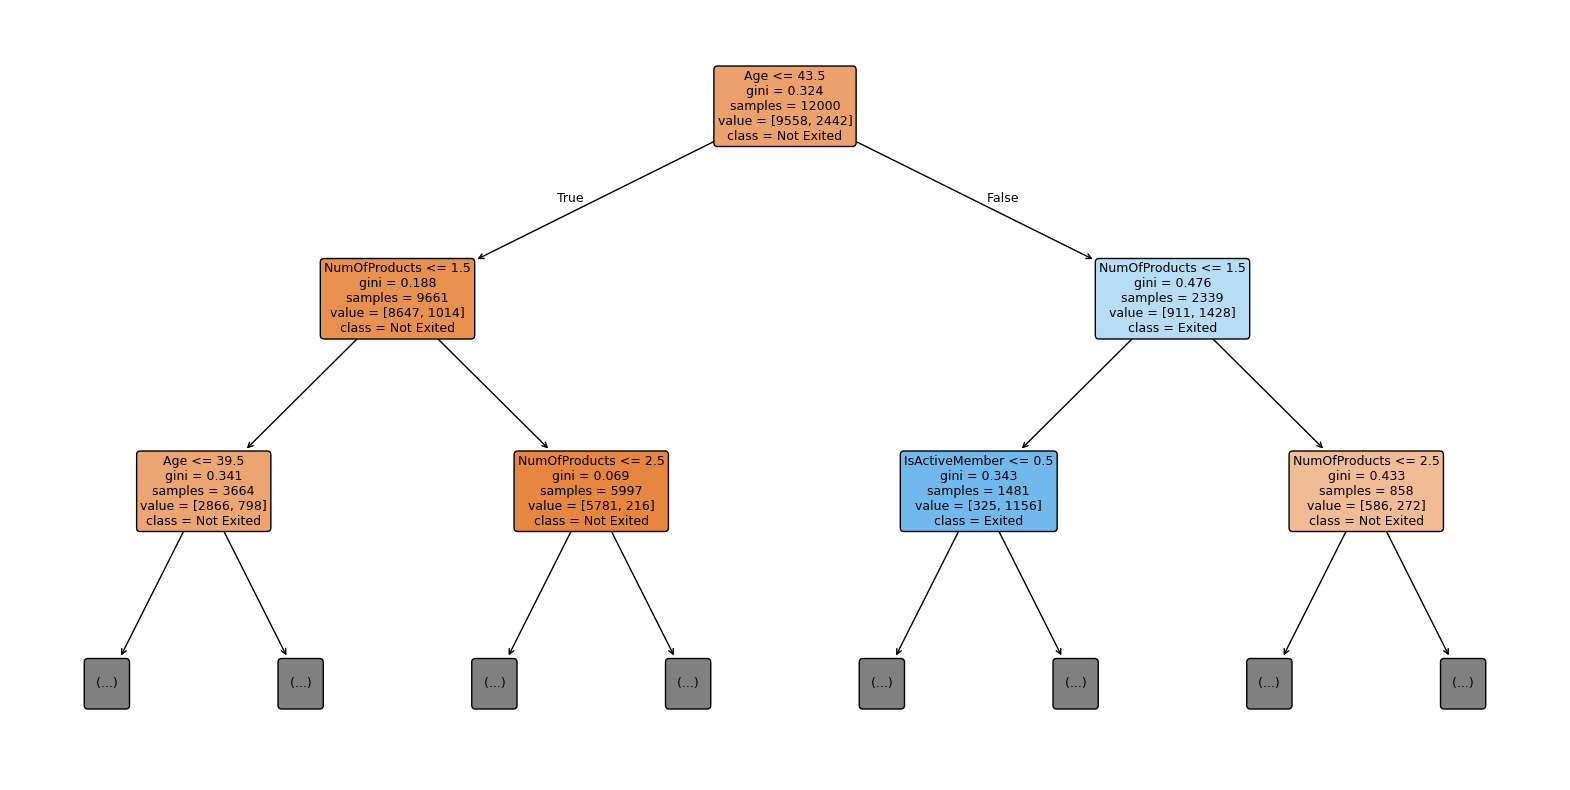

In [9]:
plt.figure(figsize=(20, 10))

plot_tree(
    tree_model,
    feature_names=X_train.columns,
    class_names=['Not Exited', 'Exited'],
    filled=True,
    rounded=True,
    max_depth=2,
    fontsize=9
)

plt.show()

На верхніх рівнях дерева найважливішими ознаками є Age, NumOfProducts та IsActiveMember. Найбільший вплив на прогноз має вік клієнта (Age), оскільки саме за ним виконується перший поділ даних.

In [10]:
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': tree_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by='importance',
    ascending=False
)

importance_df.head(10)

,feature,importance
1,Age,0.356789
4,NumOfProducts,0.168379
7,EstimatedSalary,0.123635
0,CreditScore,0.123283
3,Balance,0.079192
2,Tenure,0.052899
6,IsActiveMember,0.032688
11,Gender_Female,0.014908
9,Geography_Germany,0.014725
5,HasCrCard,0.012957


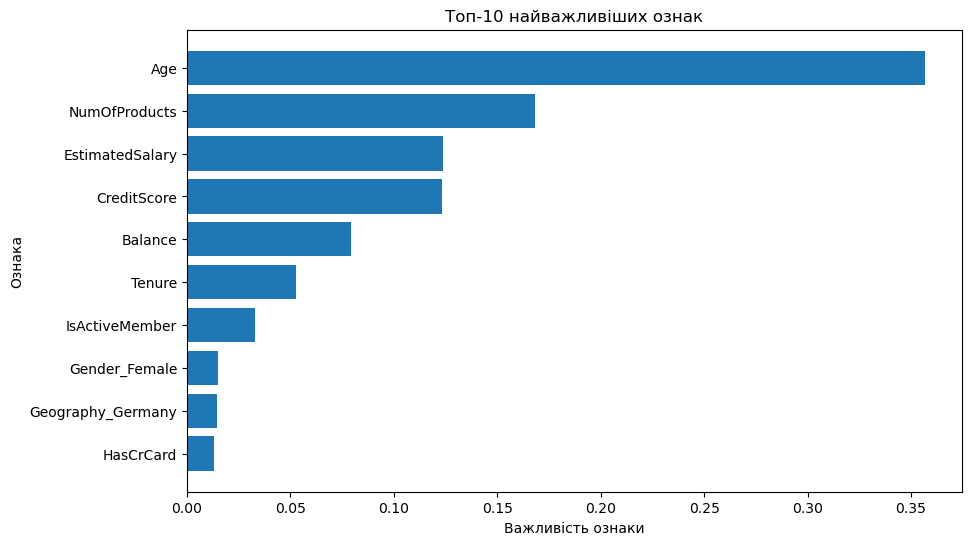

In [11]:
top_10_features = importance_df.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_10_features['feature'],
    top_10_features['importance']
)

plt.xlabel('Важливість ознаки')
plt.ylabel('Ознака')
plt.title('Топ-10 найважливіших ознак')

plt.gca().invert_yaxis()

plt.show()

**Завдання 3**. Спробуйте знайти такі параметри моделі `DecisionTree` аби модель генералізувала ліпше (був вищий показник AUROC на валідаційній вибірці). Проекспериментуйте з різними значеннями параметрів `max_leaf_nodes`, `max_depth` та лишіть ті, які дають найкращий результат, разом з відповідними AUROC на тренувальній і валідаційній вибірках.

В цьому завданні спробуйте просто знайти параметри методом "тика" :)

In [12]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score

parameters = [
    (3, 10),
    (4, 15),
    (5, 20),
    (6, 30),
    (7, 40),
    (8, 50)
]

for depth, leaves in parameters:

    model = DecisionTreeClassifier(
        random_state=42,
        max_depth=depth,
        max_leaf_nodes=leaves
    )

    model.fit(X_train, train_targets)

    train_probs = model.predict_proba(X_train)[:, 1]
    val_probs = model.predict_proba(X_val)[:, 1]

    train_auc = roc_auc_score(train_targets, train_probs)
    val_auc = roc_auc_score(val_targets, val_probs)

    print(
        f"max_depth={depth}, "
        f"max_leaf_nodes={leaves}, "
        f"Train AUC={train_auc:.4f}, "
        f"Validation AUC={val_auc:.4f}"
    )

max_depth=3, max_leaf_nodes=10, Train AUC=0.8972, Validation AUC=0.8911
max_depth=4, max_leaf_nodes=15, Train AUC=0.9113, Validation AUC=0.9113
max_depth=5, max_leaf_nodes=20, Train AUC=0.9163, Validation AUC=0.9160
max_depth=6, max_leaf_nodes=30, Train AUC=0.9264, Validation AUC=0.9227
max_depth=7, max_leaf_nodes=40, Train AUC=0.9298, Validation AUC=0.9246
max_depth=8, max_leaf_nodes=50, Train AUC=0.9312, Validation AUC=0.9238


In [13]:
best_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=7,
    max_leaf_nodes=40
)

best_model.fit(X_train, train_targets)

train_auc = roc_auc_score(
    train_targets,
    best_model.predict_proba(X_train)[:, 1]
)

val_auc = roc_auc_score(
    val_targets,
    best_model.predict_proba(X_val)[:, 1]
)

print(f"Train ROC AUC: {train_auc:.4f}")
print(f"Validation ROC AUC: {val_auc:.4f}")

Train ROC AUC: 0.9298
Validation ROC AUC: 0.9246


Найкращий результат показала модель з параметрами max_depth = 7 та max_leaf_nodes = 40. Вона отримала ROC AUC = 0.9298 на тренувальній вибірці та ROC AUC = 0.9246 на валідаційній. Оскільки значення метрик дуже близькі, модель добре узагальнює дані та не демонструє помітного перенавчання.

**Завдання 4**. В циклі пройдіться по значенням max_depth від 1 до 20 включно, на кожній ітерації натренуйте DecisionTree модель і виміряйте AUROC на трейн і валідаційних даних.

В кінці виведіть на графік залеєність між AUROC на трейн і валідаційних даних і номером ітерації.

In [15]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt


depth_values = range(1, 21)

train_auc_scores = []
val_auc_scores = []


for depth in depth_values:

    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, train_targets)

    train_probs = model.predict_proba(X_train)[:, 1]
    val_probs = model.predict_proba(X_val)[:, 1]

    train_auc = roc_auc_score(train_targets, train_probs)
    val_auc = roc_auc_score(val_targets, val_probs)

    train_auc_scores.append(train_auc)
    val_auc_scores.append(val_auc)

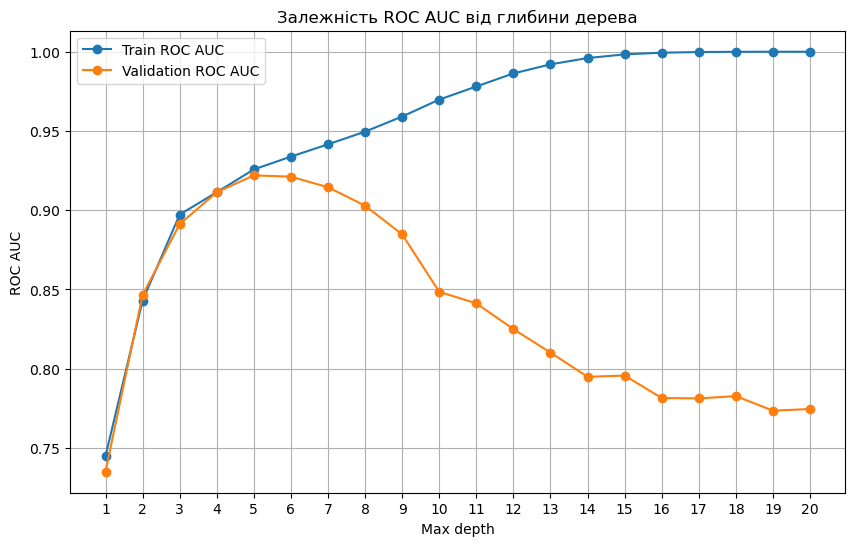

In [16]:
plt.figure(figsize=(10, 6))

plt.plot(
    depth_values,
    train_auc_scores,
    marker='o',
    label='Train ROC AUC'
)

plt.plot(
    depth_values,
    val_auc_scores,
    marker='o',
    label='Validation ROC AUC'
)

plt.xlabel('Max depth')
plt.ylabel('ROC AUC')
plt.title('Залежність ROC AUC від глибини дерева')

plt.xticks(range(1, 21))
plt.legend()
plt.grid()

plt.show()

ROC AUC на тренувальній вибірці постійно зростає і майже досягає 1. Водночас ROC AUC на валідаційній вибірці найбільший при max_depth = 5, а потім знижується. Отже, після глибини 5 модель починає перенавчатися.

**Завдання 5**.
1. Натренуйте модель `DecisionTree` з найкращим значенням `max_depth`, яке ви знайшли на попередній ітерації.
2. Завантажте тестові дані змагання з `test.csv`.
3. Зробіть попередню обробку даних з функцією `preprocess_new_data` з вашого модуля `process_bank_churn.py`.
4. Зробіть передбачення використовуючи цю модель на тестових даних змагання.
5. Сформуйте `submission.csv`.
6. Зробіть новий Submission на Kaggle і додайте тут скріншот Вашого скору на паблік лідерборді :)


In [21]:
import pandas as pd

from sklearn.tree import DecisionTreeClassifier
from process_bank_churn import preprocess_data, preprocess_new_data


train_df = pd.read_csv("train.csv")

(
    X_train,
    train_targets,
    X_val,
    val_targets,
    input_cols,
    scaler,
    encoder
) = preprocess_data(
    train_df,
    scaler_numeric=False
)

In [23]:
best_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

best_model.fit(X_train, train_targets)

print("Модель успішно навчена")

Модель успішно навчена


In [24]:
test_df = pd.read_csv("test.csv")

test_ids = test_df["id"].copy()

In [26]:
X_test = preprocess_new_data(
    test_df,
    input_cols=input_cols,
    scaler=scaler,
    encoder=encoder
)

In [27]:
test_predictions = best_model.predict_proba(X_test)[:, 1]

In [28]:
submission = pd.DataFrame({
    "id": test_ids,
    "Exited": test_predictions
})

submission.to_csv("submission.csv", index=False)

submission.head()

,id,Exited
0,15000,0.237911
1,15001,0.027613
2,15002,0.027613
3,15003,0.770925
4,15004,0.027613


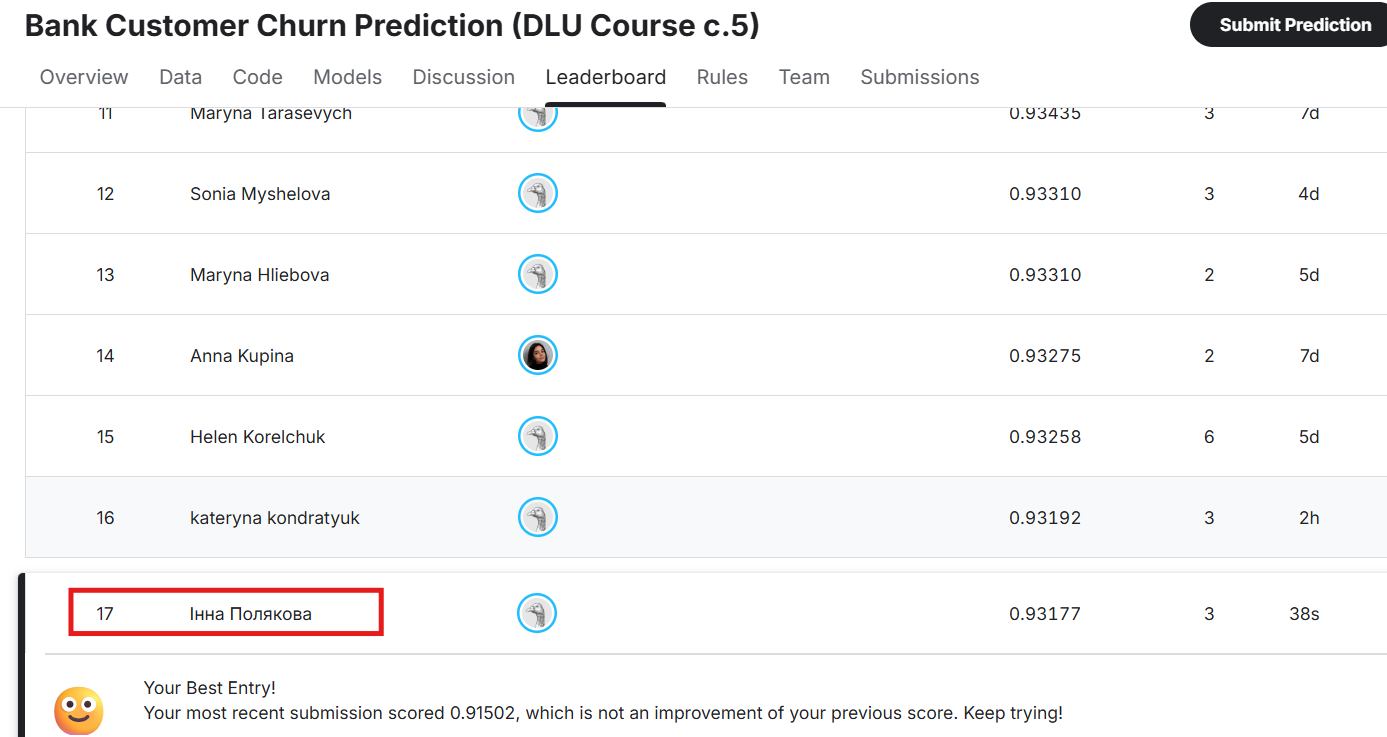